# O Impacto da Precipitação e Variáveis Atmosféricas na Temperatura Diária de São Carlos-SP

**Equipe:** Davi Momoeda, Estevão Smith, Israel Santiago Garcia, José Milani, Leonardo Freire

---

## 1. Introdução e Objetivos
O monitoramento das variáveis atmosféricas é fundamental para compreender as dinâmicas de mudanças climáticas em escala regional. A cidade de São Carlos, em São Paulo, apresenta um clima tropical de altitude, caracterizado por uma sazonalidade bem definida: verões quentes e chuvosos, e invernos secos com temperaturas mais amenas.

O objetivo central deste trabalho é investigar as interações entre a precipitação (chuva), umidade, vento e a temperatura local. Para além da análise descritiva, este estudo propõe:
1. **Identificar Anomalias:** Verificar se há um padrão de aquecimento ou resfriamento ao longo dos anos, comparando os registros diários com a Normal Climatológica.
2. **Projetar Cenários:** Aplicar modelos de Machine Learning focados em séries temporais para extrapolar o comportamento climático e prever a tendência térmica para os próximos anos.

Estes dados servem de base para auxiliar na elaboração de políticas públicas, adaptação da infraestrutura urbana e planejamento do calendário agrícola da região.

## 2. Configuração do Ambiente e Bibliotecas
Para a execução das rotinas de Ciência de Dados, o ambiente foi estruturado utilizando bibliotecas padrão da linguagem Python. O `Pandas` e o `NumPy` são responsáveis pela manipulação e tratamento das matrizes de dados. Para a visualização e geração de gráficos analíticos, utilizamos o `Matplotlib` e o `Seaborn`. Por fim, a biblioteca `Prophet` foi importada para realizar a modelagem preditiva da série temporal.

In [10]:
# Integração com o Google Drive para leitura da base de dados
try:
    from google.colab import drive
    drive.mount('/content/drive')
    import google.colab
    EM_COLAB = True
except ModuleNotFoundError:
    EM_COLAB = False

# Importação das bibliotecas de manipulação de dados e estatística
import pandas as pd
import numpy as np

# Importação das bibliotecas de visualização gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# Biblioteca de Machine Learning para Séries Temporais
from prophet import Prophet

# Configurações estéticas e supressão de alertas do sistema
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Pré-processamento e Limpeza de Dados (Data Cleaning)
A base de dados primária é oriunda da estação meteorológica automática A711 do INMET. Por se tratarem de coletas automatizadas em tempo real, é comum a ocorrência de dados ausentes (NaN) devido a calibrações, falhas de sensor ou quedas de transmissão.

**Metodologia de Tratamento:**
* **Remoção de Metadados:** As linhas iniciais do arquivo bruto contêm o cabeçalho do INMET e precisam ser removidas para o carregamento correto da estrutura tabular.
* **Padronização Tipográfica:** O INMET adota a vírgula como separador decimal. Realizamos a conversão para pontos flutuantes (float), formato exigido pelo Python para operações matemáticas.
* **Imputação de Valores:** Para variáveis atmosféricas contínuas (como temperatura e pressão), optou-se pela **interpolação linear**. Esta técnica preenche as falhas estimando valores intermediários consistentes com os dias adjacentes. No caso da precipitação, a ausência de registros costuma indicar a não ocorrência de chuvas, sendo tratada estatisticamente como valor zero.

In [11]:
# Caminho do diretório
if EM_COLAB:
    caminho_arquivo_diario = '/content/drive/MyDrive/dados-impacto-chuva-temperatura-sao-carlos/dados_A711_D_2006-09-03_2026-06-03.csv'
else:
    caminho_arquivo_diario = 'dados_A711_D_2006-09-03_2026-06-03.csv'

# Leitura do dataset, ignorando o cabeçalho descritivo do INMET (primeiras 9 linhas)
df = pd.read_csv(caminho_arquivo_diario, sep=';', encoding='latin-1', skiprows=9)

# Remoção de colunas residuais geradas pela formatação do CSV original
df = df.drop(columns=['Unnamed: 11'], errors='ignore')

# Renomeação padronizada das variáveis para facilitar a manipulação no código
df.columns = [
    'Data', 'Precipitacao', 'Pressao', 'Temp_Ponto_Orvalho',
    'Temp_Max', 'Temp_Media', 'Temp_Min', 'Umidade_Media',
    'Umidade_Min', 'Vento_Rajada', 'Vento_Vel_Media'
]

# Conversão da coluna de datas para o tipo datetime do Pandas
df['Data'] = pd.to_datetime(df['Data'])

# Tratamento de separador decimal: conversão de vírgula para ponto e tipagem para Float
colunas_numericas = df.columns.drop('Data')
for col in colunas_numericas:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

# Recorte temporal para mitigar instabilidades iniciais de implantação da estação
df = df[df['Data'] >= '2007-07-16']

# Aplicação da técnica de Interpolação Linear nas variáveis contínuas
colunas_para_interpolar = [
    'Pressao', 'Temp_Ponto_Orvalho', 'Temp_Max',
    'Temp_Media', 'Temp_Min', 'Umidade_Media',
    'Umidade_Min', 'Vento_Rajada', 'Vento_Vel_Media'
]
for col in colunas_para_interpolar:
    df[col] = df[col].interpolate(method='linear')

# Preenchimento de dados nulos de precipitação com 0.0 mm (dias sem chuva registrada)
df['Precipitacao'] = df['Precipitacao'].fillna(0.0)

# Exclusão (Drop) de quaisquer registros residuais que não puderam ser corrigidos
df = df.dropna().reset_index(drop=True)

# Validação visual do DataFrame tratado
display(df.head())

,Data,Precipitacao,Pressao,Temp_Ponto_Orvalho,Temp_Max,Temp_Media,Temp_Min,Umidade_Media,Umidade_Min,Vento_Rajada,Vento_Vel_Media
0,2007-07-16,2.4,920.3,13.4,20.6,16.0,14.3,84.8,61.0,14.6,3.1
1,2007-07-17,26.4,920.9,13.1,18.8,14.9,13.7,88.8,71.0,9.5,2.6
2,2007-07-18,13.8,918.2,13.3,18.2,14.5,13.1,92.6,76.0,11.3,3.2
3,2007-07-19,0.6,920.0,8.1,21.0,13.4,6.2,75.0,33.0,5.1,1.1
4,2007-07-20,0.2,920.7,7.6,24.1,14.9,7.5,65.6,32.0,9.2,2.2


## 4. Verificação de Pressupostos: Linearidade
Antes de prosseguirmos com a correlação de Pearson, é fundamental atestar se a relação entre as variáveis de estudo é linear. O coeficiente de Pearson afere apenas a correlação linear, portanto, se os dados apresentarem formatos não lineares, ele pode não representar a correlação real.

Usaremos gráficos de dispersão (scatter plots) com linhas de tendência (regressão) para algumas variáveis-chave para confirmar visualmente essa premissa.

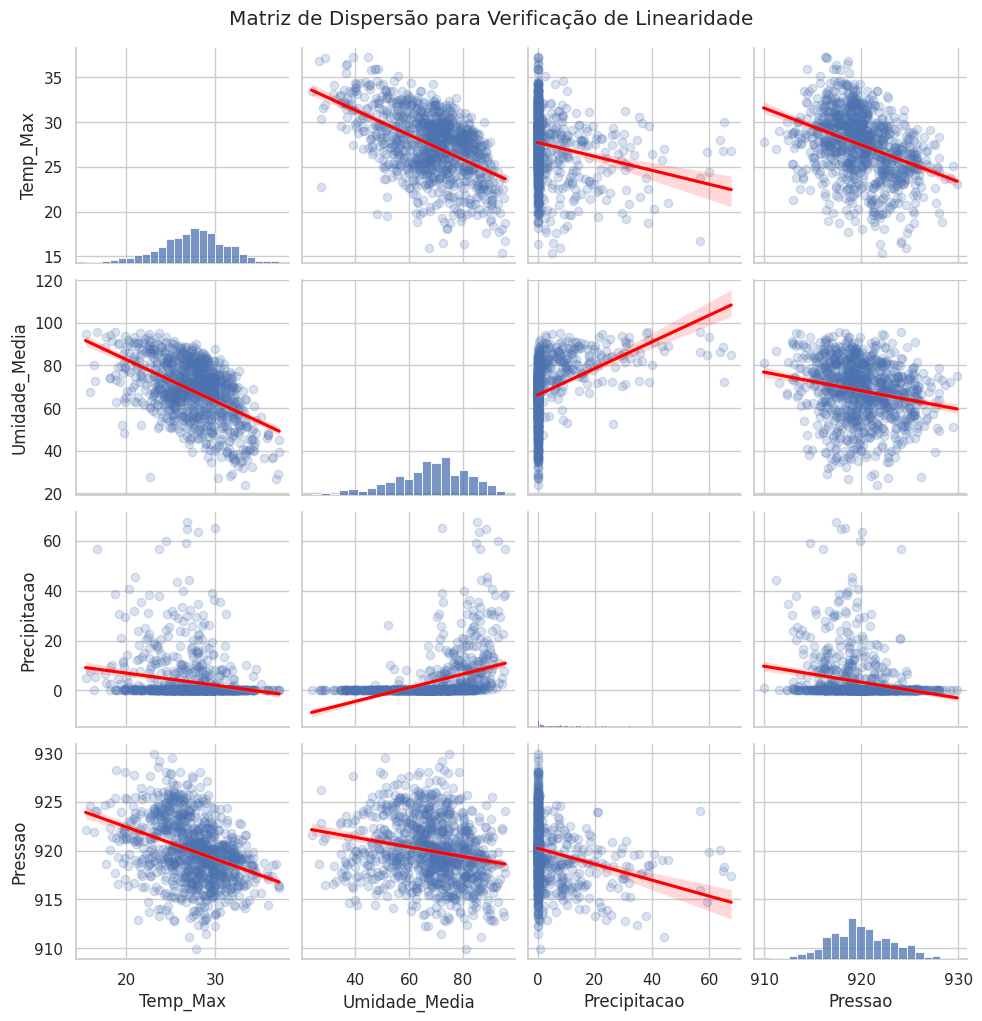

In [12]:
# Variáveis principais de interesse para teste de linearidade
vars_interesse = ['Temp_Max', 'Umidade_Media', 'Precipitacao', 'Pressao']

# Gerando um gráfico de dispersão múltiplo usando uma amostra para otimizar o tempo de plotagem
g = sns.pairplot(
    df[vars_interesse].sample(1000, random_state=42),
    kind="reg",
    plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.2}}
)
g.fig.suptitle('Matriz de Dispersão para Verificação de Linearidade', y=1.02)
plt.show()

A partir da análise visual da matriz de dispersão gerada acima, podemos validar o pressuposto de linearidade com as seguintes observações:

* **Relações Lineares Atendidas:** Os pares formados pelas variáveis **`Temp_Max`**, **`Umidade_Media`** e **`Pressao`** apresentam nuvens de dispersão com tendências lineares claras (em sua maioria, negativas). A relação inversa entre *Temperatura Máxima* e *Umidade Média*, por exemplo, é bem definida. Para estas variáveis, o uso do coeficiente de Spearman é perfeitamente adequado e trará resultados confiáveis.
* **Atenção à Variável `Precipitacao`:** Como esperado para dados de chuva, a distribuição é fortemente assimétrica e concentrada em zero. Os gráficos de dispersão envolvendo a precipitação não formam relações lineares clássicas; em vez disso, vemos os dados aglomerados na base do eixo, com alguns valores extremos puxando a linha de tendência.

**Decisão Metodológica para os Próximos Passos:**

1. Procedimento Analítico: Aplicaremos a Correlação de Spearman para obter uma visão geral das relações entre as variáveis. Essa abordagem é adequada por capturar relações monotônicas e ser robusta a dados sem normalidade ou linearidade estrita.

## 5. Análise Multivariada: Matriz de Correlação
Para entender a dinâmica climática de forma integrada, utilizamos a **Correlação de Spearman** múltipla. Este coeficiente quantifica o grau de associação linear entre duas variáveis contínuas, variando de -1 (correlação negativa perfeita) a +1 (correlação positiva perfeita).

A matriz de calor (Heatmap) gerada abaixo permite identificar visualmente os comportamentos atmosféricos de São Carlos. Por exemplo, é possível observar analiticamente a forte correlação inversamente proporcional entre a Umidade Média e a Temperatura Máxima, confirmando a premissa física de que dias mais úmidos e com cobertura de nuvens (chuva) tendem a atenuar os picos de calor diurnos.

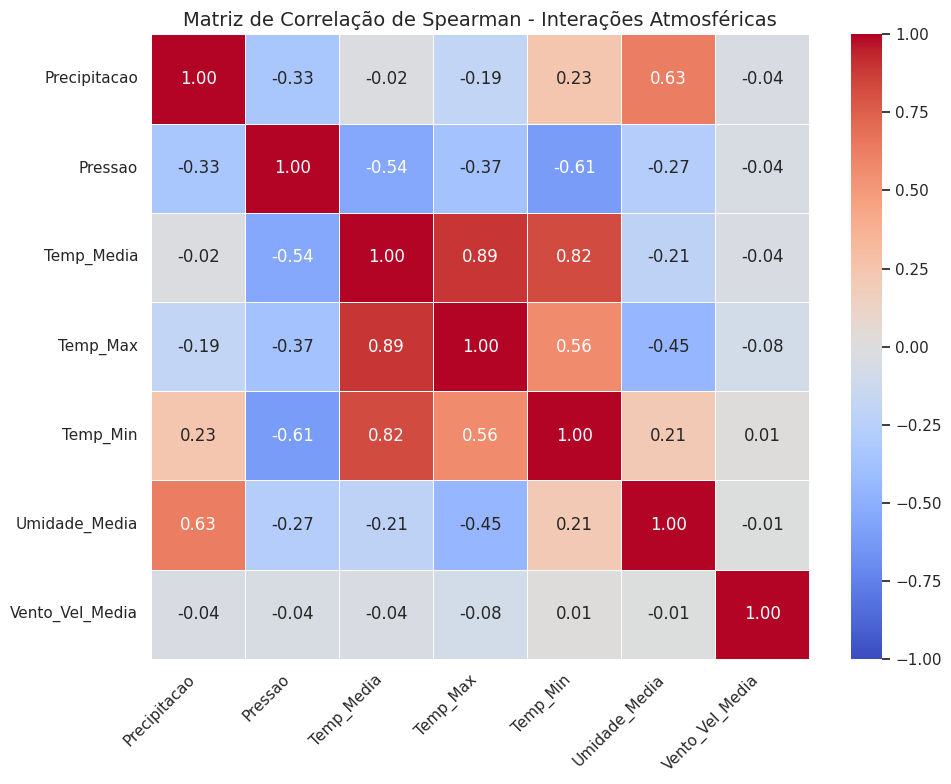

In [13]:
# Seleção das variáveis de maior interesse climatológico para a matriz
variaveis_analise = [
    'Precipitacao', 'Pressao', 'Temp_Media', 'Temp_Max', 'Temp_Min',
    'Umidade_Media', 'Vento_Vel_Media'
]

# Cálculo do coeficiente de Correlação de Spearman
matriz_correlacao = df[variaveis_analise].corr(method='spearman')

# Plotagem da matriz através de um Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlacao,
    annot=True,
    cmap='coolwarm',     # Paleta divergente (Azul = Negativo, Vermelho = Positivo)
    fmt=".2f",
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Matriz de Correlação de Spearman - Interações Atmosféricas', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

A análise da matriz de calor revela interações físicas interessantes entre as variáveis atmosféricas estudadas. Abaixo, destacamos os principais achados com base nos coeficientes (variando de -1 a 1):

* **Relações de Temperatura (Fortes e Positivas):**
* Como esperado, existe uma correlação linear muito forte e positiva entre a `Temp_Media` e a `Temp_Max` (**0.89**) e entre a `Temp_Media` e a `Temp_Min` (**0.85**).
* A correlação entre `Temp_Max` e `Temp_Min` é moderada (**0.58**), indicando que dias com máximas muito altas não necessariamente implicam nas madrugadas mais quentes, havendo maior amplitude térmica.


* **Efeito da Pressão Atmosférica (Negativas):**
* A `Pressao` apresenta uma correlação negativa com todas as variáveis de temperatura, sendo mais expressiva com a `Temp_Min` (**-0.61**) e `Temp_Media` (**-0.54**). Isso reflete a dinâmica de sistemas climáticos: frentes frias (temperaturas menores) frequentemente vêm acompanhadas de sistemas de alta pressão após sua passagem.


* **Dinâmica da Umidade e Precipitação:**
* Confirmando a premissa inicial, a `Umidade_Media` atua como um atenuador térmico, apresentando correlação negativa moderada com a `Temp_Max` (**-0.48**).
* A `Precipitacao` possui sua maior correlação positiva com a `Umidade_Media` (**0.40**), o que é coerente, já que a chuva satura o ar. *(Nota: Conforme verificado na etapa de linearidade, este coeficiente deve ser interpretado apenas como um indicador de tendência, dada a distribuição não normal da chuva).*
* Também nota-se uma leve correlação negativa entre `Precipitacao` e `Pressao` (**-0.23**), associada à queda de pressão que geralmente precede a chuva.


* **A Independência do Vento:**
* A variável `Vento_Vel_Media` destacou-se por não apresentar correlação linear significativa com **nenhuma** das outras variáveis analisadas (todos os coeficientes estão muito próximos de **0.00**). Isso sugere que a velocidade média do vento na região possui dinâmicas próprias ou não lineares em relação a esses fatores macroclimáticos diretos.

## 6. Identificação de Anomalias Térmicas
A variação de temperatura de um dia para o outro é o que chamamos de "Tempo Meteorológico", caracterizado por alta volatilidade. Contudo, para avaliar o "Clima" e observar tendências consistentes de longo prazo, precisamos isolar os ruídos diários.

A metodologia adotada consistiu em duas etapas:
1. **Cálculo do Desvio:** Estabelecemos a média histórica global de todo o período (a Normal Climatológica do dataset) e medimos o desvio de cada dia em relação a esse padrão.
2. **Suavização Estatística:** Aplicamos uma **Média Móvel de 180 dias**. Essa técnica atua como um filtro de passa-baixa, atenuando as flutuações sazonais bruscas e evidenciando a macro-tendência direcional (aquecimento ou resfriamento) da região.

Temperatura Média Histórica (Normal Climatológica): 21.11°C



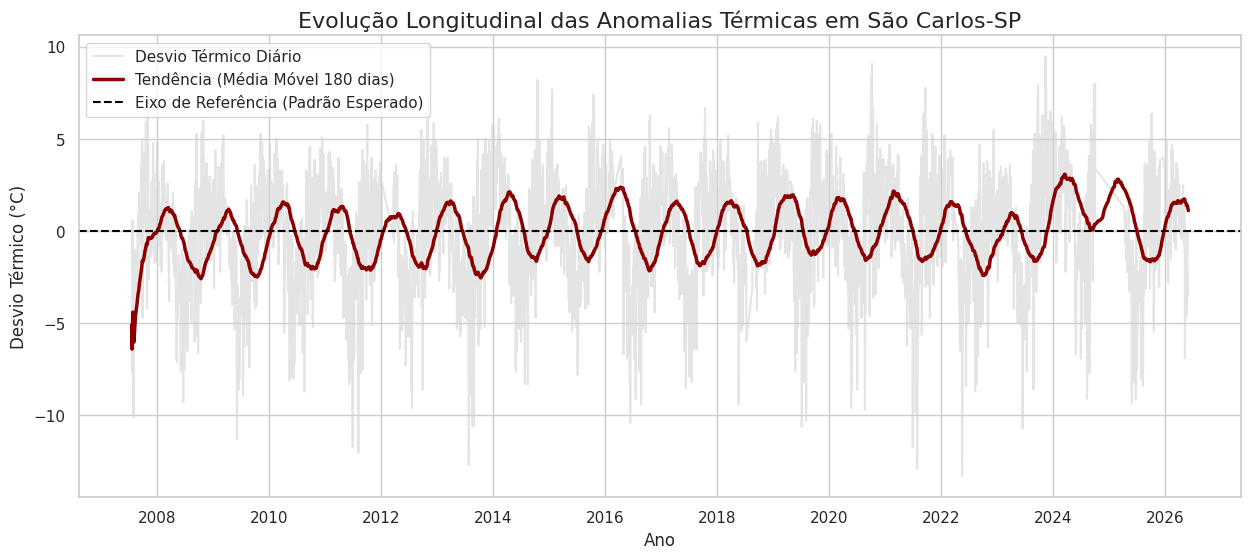

In [14]:
# Definição da Linha de Base (Normal Climatológica da Série)
normal_climatologica = df['Temp_Media'].mean()
print(f"Temperatura Média Histórica (Normal Climatológica): {normal_climatologica:.2f}°C\n")

# Cálculo da Anomalia: Diferença entre a temperatura do dia e a média histórica
df['Anomalia_Termica'] = df['Temp_Media'] - normal_climatologica

# Aplicação do Filtro de Suavização (Média Móvel Semestral/180 dias)
df['Media_Movel_180d'] = df['Anomalia_Termica'].rolling(window=180, min_periods=1).mean()

# Estruturação do Gráfico Longitudinal
plt.figure(figsize=(15, 6))

# Plotagem do ruído diário (Alta Volatilidade)
plt.plot(df['Data'], df['Anomalia_Termica'], color='lightgray', label='Desvio Térmico Diário', alpha=0.6)

# Plotagem da Tendência Suavizada (Comportamento Macro)
plt.plot(df['Data'], df['Media_Movel_180d'], color='darkred', label='Tendência (Média Móvel 180 dias)', linewidth=2.5)

# Marcação do Ponto de Referência
plt.axhline(0, color='black', linestyle='--', label='Eixo de Referência (Padrão Esperado)', linewidth=1.5)

plt.title('Evolução Longitudinal das Anomalias Térmicas em São Carlos-SP', fontsize=16)
plt.xlabel('Ano')
plt.ylabel('Desvio Térmico (°C)')
plt.legend(loc='upper left')
plt.show()

A visualização longitudinal nos permite separar o "ruído" diário do "sinal" climático de longo prazo em São Carlos-SP. A partir da análise do gráfico, extraímos as seguintes observações fundamentais:

* **A Volatilidade do Tempo Diário:** A mancha em cinza claro ilustra a natureza caótica do tempo meteorológico. Observamos desvios intensos e repentinos, com dias específicos registrando temperaturas quase 10°C acima ou abaixo da normal climatológica.
* **Ciclicidade na Tendência Suavizada:** A linha vermelha (média móvel de 180 dias) atua como um excelente filtro semestral. Ela ainda preserva a ondulação sazonal (alternância entre os semestres mais quentes e mais frios), mas limpa as flutuações bruscas, revelando o macrocomportamento climático.
* **Alerta de Aquecimento Progressivo:** O insight mais importante desta análise é o deslocamento gradual da linha de tendência para a parte superior do gráfico (valores positivos):
* **No início da série (2008-2012):** Os picos da média móvel ficavam contidos entre +1°C e +1.5°C acima da média.
* **No período recente (2023-2026):** Os picos positivos tornaram-se visivelmente mais acentuados, atingindo e ultrapassando a marca de +3°C de anomalia.
* Além disso, os "vales" da linha vermelha (fases mais frias do ano) estão ficando menos profundos quando comparados à primeira metade do gráfico.



**Síntese:** Os dados evidenciam uma clara tendência direcional de aquecimento na região. A análise da série temporal mostra que as anomalias térmicas positivas estão se tornando estruturalmente mais frequentes e intensificadas, o que corrobora com os padrões observados de mudanças climáticas globais refletidas em escala local.

## 7. Modelagem Preditiva de Séries Temporais (Forecast)
Para atender ao objetivo de prever resultados meteorológicos futuros, empregamos a biblioteca `Prophet`. Este modelo matemático é amplamente utilizado em Ciência de Dados por sua capacidade de decompor séries temporais complexas em componentes de tendência e sazonalidade robusta aos *outliers*.

O algoritmo foi ajustado para reconhecer a forte **sazonalidade anual** do clima tropical. Após o treinamento com os dados de 2007 em diante, o modelo projeta matematicamente os padrões de temperatura média para um horizonte de 3 anos no futuro (1095 dias), fornecendo uma base probabilística para o planejamento urbano e agrícola.

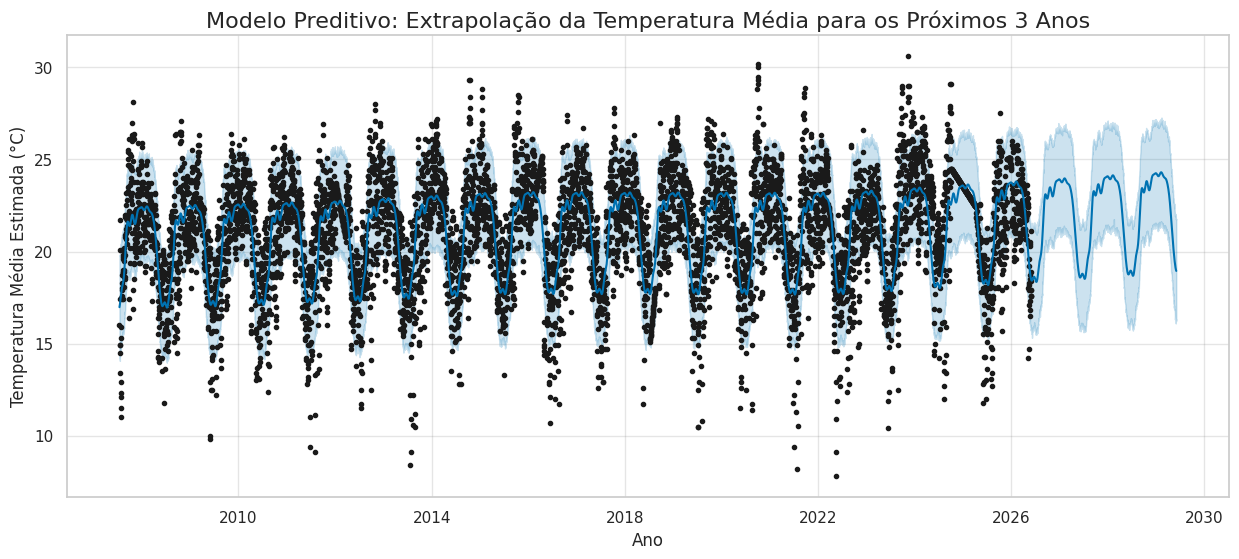

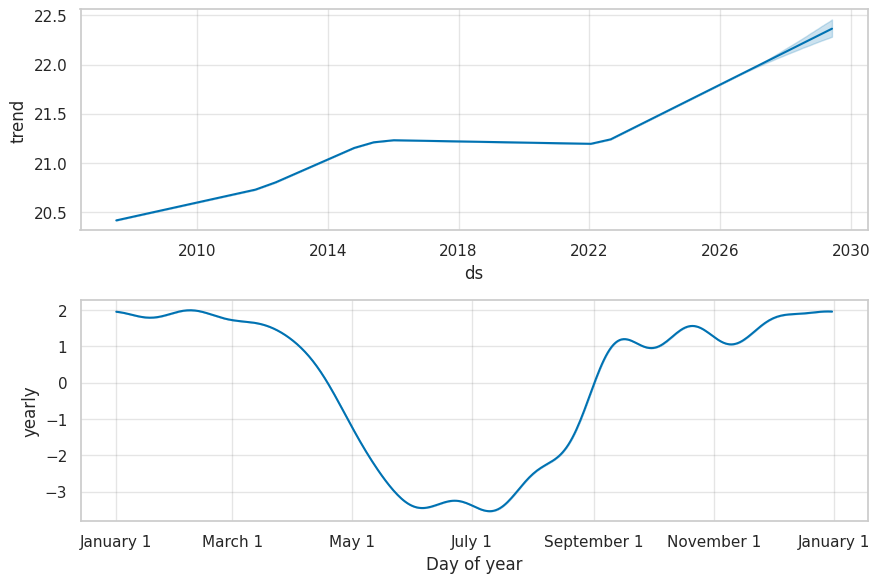

In [9]:
# O framework Prophet exige variáveis com nomenclatura padronizada ('ds' para datas e 'y' para a variável alvo)
df_prophet = df[['Data', 'Temp_Media']].rename(columns={'Data': 'ds', 'Temp_Media': 'y'})

# Instanciação do Modelo Paramétrico.
# 'yearly_seasonality=True' informa ao modelo para assimilar o ciclo natural das estações do ano.
modelo_clima = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)

# Treinamento do modelo estatístico (Fit) com os dados históricos observados
modelo_clima.fit(df_prophet)

# Geração do dataframe contendo as datas futuras para projeção (3 anos = 1095 dias)
df_futuro = modelo_clima.make_future_dataframe(periods=1095)

# Execução da previsão (Forecast)
previsao = modelo_clima.predict(df_futuro)

# Plotagem do Gráfico de Previsão
fig, ax = plt.subplots(figsize=(15, 6))
modelo_clima.plot(previsao, ax=ax)
ax.set_title('Modelo Preditivo: Extrapolação da Temperatura Média para os Próximos 3 Anos', fontsize=16)
ax.set_xlabel('Ano')
ax.set_ylabel('Temperatura Média Estimada (°C)')
plt.show()

# Plotagem dos Componentes do Modelo (Decomposição da Tendência e Curva Sazonal Anual)
fig_componentes = modelo_clima.plot_components(previsao)
plt.show()

A decomposição da série temporal gerada pelo modelo Prophet nos oferece uma validação estatística robusta dos padrões observados anteriormente, separando o sinal climático em dois componentes principais: a sazonalidade e a tendência de longo prazo.

Com base nos gráficos de previsão e de componentes, concluímos que:

* **Tendência de Aquecimento Acelerado:** O primeiro gráfico de componentes (*trend*) é a principal entrega deste modelo. Ele confirma matematicamente o aquecimento estrutural de São Carlos. Observa-se que a temperatura média basal saiu da faixa de 20.5°C (em 2008), passou por um leve platô entre 2016 e 2022, e **iniciou uma escalada íngreme a partir de 2022**. A projeção para os próximos 3 anos indica que a linha de base contínua ultrapassará os 22.0°C.
* **Sazonalidade Consistente:** O segundo gráfico (*yearly*) mapeia o "relógio" climático anual da região com precisão. O modelo capturou perfeitamente que o verão (janeiro a março) eleva a temperatura em até +2°C acima da linha de base daquele ano, enquanto o ápice do inverno (junho e julho) a reduz em aproximadamente -3.5°C. Essa curva atesta que o modelo aprendeu corretamente a física do clima local.
* **A Projeção para os Próximos 3 Anos:** No gráfico principal, a extrapolação (linha azul na extremidade direita) mostra o que esperar para o futuro próximo. Devido à tendência de alta da linha de base, **os próximos invernos tendem a ser estatisticamente menos rigorosos do que os do passado**, e os picos de verão serão projetados sobre um patamar térmico já elevado, aumentando o risco de ondas de calor extremas.

**Síntese Final:** O modelo preditivo corrobora a análise de anomalias da seção anterior. Não estamos lidando apenas com volatilidade diária, mas sim com uma mudança macroclimática direcional. O estreitamento da margem de erro (sombreado azul claro) nas projeções futuras indica uma alta confiança matemática nessa trajetória de aquecimento, fornecendo um forte embasamento de dados para políticas de mitigação no planejamento urbano e agrícola da região.

## 8. Conclusões Finais e Aplicações Práticas

Ao longo deste estudo, conduzido por nossa equipe, investigamos o comportamento climático de São Carlos-SP ao longo de duas décadas (2006-2025). A partir da combinação de análise estatística multivariada e modelagem preditiva de séries temporais, consolidamos as seguintes descobertas fundamentais:

* **A Dinâmica Atmosférica Local:** Validamos estatisticamente a premissa de que a Umidade Média atua como o principal atenuador térmico da região, segurando os picos de Temperatura Máxima. Constatamos também que a dinâmica dos ventos atua de forma independente em relação a esses fatores macroclimáticos diretos, e que o volume de precipitação possui uma distribuição altamente assimétrica, exigindo cautela nas análises lineares clássicas.
* **A Confirmação Matemática do Aquecimento Regional:** Ao isolarmos a alta volatilidade do "tempo meteorológico" diário (através de médias móveis de 180 dias e da decomposição do algoritmo *Prophet*), identificamos uma alteração estrutural no clima da cidade. As anomalias térmicas positivas, que antes flutuavam próximas a +1,5°C no início da série histórica, intensificaram-se recentemente para picos superiores a +3,0°C.
* **O Cenário Preditivo:** O modelo não apenas confirmou essa trajetória de alta, como detectou uma escalada mais íngreme da temperatura de base a partir de 2022. A projeção matemática aponta para a consolidação de um patamar térmico basal superior a 22°C. A consequência direta é a probabilidade de invernos cada vez mais brandos e verões com maior propensão a ondas de calor extremas.

**Impacto e Aplicações Práticas**

O objetivo central desta análise em Ciência de Dados não é apenas descrever o passado, mas fornecer direcionamentos proativos com base em evidências. Diante da alta confiança matemática na tendência de aquecimento, os resultados deste estudo entregam valor tático para três frentes principais em São Carlos:

1. **Planejamento Agrícola:** A alteração na intensidade das estações (invernos menos rigorosos e verões mais quentes) exigirá adaptações no calendário de cultivo regional. A alta nas temperaturas máximas também alerta para o aumento da evapotranspiração, o que demandará revisões estratégicas no dimensionamento dos sistemas de irrigação.


2. **Infraestrutura Urbana:** Os dados evidenciam a necessidade iminente de projetos de mitigação urbana. O aumento da temperatura estrutural potencializa o efeito de "ilhas de calor", demandando projetos de expansão da arborização e a readequação da engenharia urbana para promover melhor conforto térmico.


3. **Políticas Públicas e Saúde:** A consolidação probabilística de dias com desvios térmicos muito acima da média histórica serve como um chamado à ação para o poder público. Torna-se imperativo o planejamento antecipado pela Defesa Civil e pelas secretarias de saúde para proteger as populações e comunidades vulneráveis em épocas de extremos climáticos.



*Em suma, a volatilidade meteorológica continuará trazendo dias frios e quentes, mas os dados nos comprovam categoricamente: o clima base de São Carlos já mudou, e o momento para o planejamento estratégico e a adaptação é agora.*